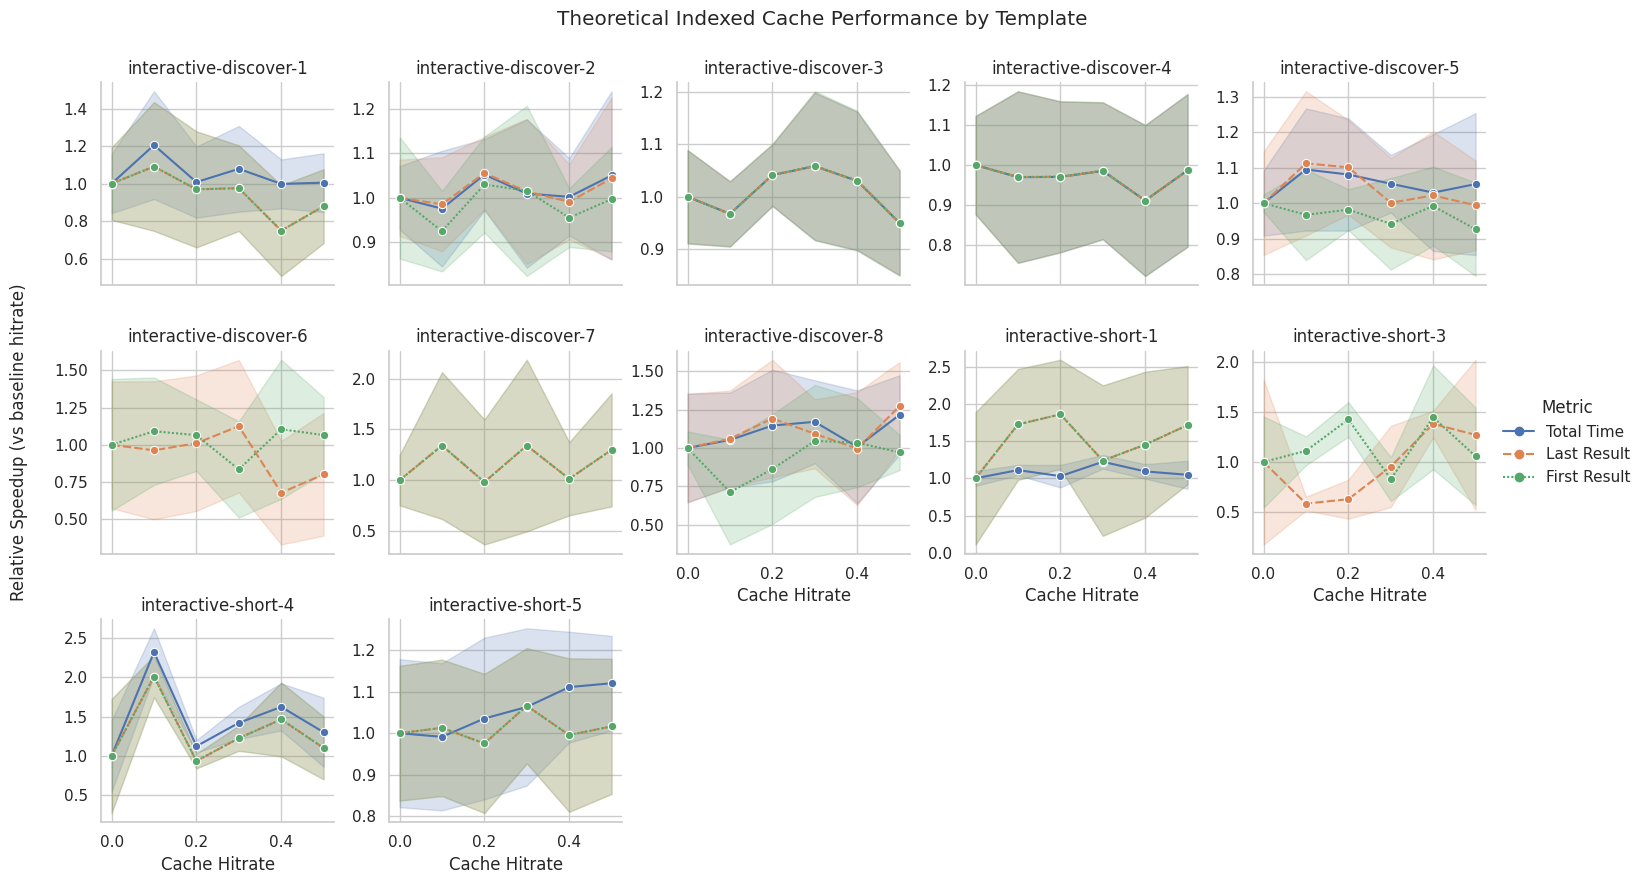

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import glob
import re
import os


def load_and_process_data(directory, file_pattern="query-results-raw-hitrate-*.json"):
    data = []

    # 1. Load Data
    for filepath in glob.glob(os.path.join(directory, file_pattern)):
        match = re.search(r'hitrate-([0-9.]+)', filepath)
        if not match:
            continue
        hitrate = float(match.group(1)[:-1])

        with open(filepath, 'r') as f:
            results = json.load(f)

        for row in results:
            name = row.get("name", "")
            time = row.get("time")
            error = bool(row.get("error", False))

            timestamps = row.get("timestamps", [])
            num_timestamps = len(timestamps)
            time_first = timestamps[0] if num_timestamps > 0 else pd.NA
            time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
            has_results = num_timestamps > 0

            run_id = str(row.get("id"))
            is_first = run_id == "0"
            is_repeat = run_id == "1"

            if not (is_first or is_repeat):
                continue

            template_name = name.replace("repeat_", "")

            data.append({
                "hitrate": hitrate,
                "template": template_name,
                "is_repeat": is_repeat,
                "time": time,
                "time_first": time_first,
                "time_last": time_last,
                "num_timestamps": num_timestamps,
                "error": error,
                "has_results": has_results
            })

    df = pd.DataFrame(data)

    # Assign a repetition index within each (hitrate, template, is_repeat) group
    # so we can pair first-run and repeat-run from the same experiment repetition
    df['repetition'] = df.groupby(['hitrate', 'template', 'is_repeat']).cumcount()

    # 2. Separate First and Repeat Runs, rename columns to avoid collisions after merge
    first_runs = df[~df['is_repeat']].copy()
    first_runs.columns = [
        f"{col}_first" if col not in ['hitrate', 'template', 'repetition'] else col
        for col in first_runs.columns
    ]

    repeat_runs = df[df['is_repeat']].copy()
    repeat_runs.columns = [
        f"{col}_repeat" if col not in ['hitrate', 'template', 'repetition'] else col
        for col in repeat_runs.columns
    ]

    # Pair first and repeat runs from the same repetition
    merged = pd.merge(first_runs, repeat_runs, on=['hitrate', 'template', 'repetition'])

    # Keep only rows where both runs are valid (no error, or error but had partial results)
    valid_first = ~merged['error_first'] | (merged['error_first'] & merged['has_results_first'])
    valid_repeat = ~merged['error_repeat'] | (merged['error_repeat'] & merged['has_results_repeat'])
    valid_runs = merged[valid_first & valid_repeat].copy()

    # 3. Per-repetition speedup: first_run_time / repeat_run_time
    #
    # This is the core fix. We compute speedup for each of the 10 repetitions
    # individually before any aggregation. seaborn will then take mean + std
    # across these 10 per-repetition speedup values.
    #
    # Column naming after the merge:
    #   time_first        -> total exec time of the first run  (from first_runs, suffixed _first)
    #   time_repeat       -> total exec time of the repeat run (from repeat_runs, suffixed _repeat)
    #   time_first_first  -> time-to-first-result of the first run
    #   time_first_repeat -> time-to-first-result of the repeat run
    #   time_last_first   -> time-to-last-result of the first run
    #   time_last_repeat  -> time-to-last-result of the repeat run

    valid_runs['speedup_total'] = (
        valid_runs['time_first'] / valid_runs['time_repeat']
    )

    # Timed-out runs have no meaningful total execution time (the clock was cut off),
    # so omit Total Time for any repetition where either run errored out.
    # First/Last Result are still valid because they come from timestamps recorded
    # before the timeout.
    timed_out = valid_runs['error_first'] | valid_runs['error_repeat']
    valid_runs.loc[timed_out, 'speedup_total'] = pd.NA
    valid_runs['speedup_first_result'] = (
        valid_runs['time_first_first'] / valid_runs['time_first_repeat']
    )
    valid_runs['speedup_last_result'] = (
        valid_runs['time_last_first'] / valid_runs['time_last_repeat']
    )

    # Invalidate first/last-result speedups where the number of result rows
    # differs between the two runs (incomparable timestamps)
    valid_timestamp_match = (
        valid_runs['num_timestamps_first'] == valid_runs['num_timestamps_repeat']
    )
    valid_runs.loc[~valid_timestamp_match, ['speedup_first_result', 'speedup_last_result']] = pd.NA

    # 4. Compute baseline mean speedup per template (at the chosen baseline hitrate)
    #
    # The baseline is the mean of the per-repetition speedups at hitrate = 0.6.
    # We normalise every other hitrate's per-repetition speedup against this value,
    # so the baseline hitrate always plots at 1.0 and the error bars reflect
    # std(speedup_i / baseline_mean) = std(speedup_i) / baseline_mean.
    BASELINE_HITRATE = 0.0

    baseline = valid_runs[valid_runs['hitrate'] == BASELINE_HITRATE].copy()
    baseline_agg = baseline.groupby('template').agg(
        speedup_total_baseline=('speedup_total', 'mean'),
        speedup_first_baseline=('speedup_first_result', 'mean'),
        speedup_last_baseline=('speedup_last_result', 'mean'),
    ).reset_index()

    valid_runs = pd.merge(valid_runs, baseline_agg, on='template')

    # 5. Relative speedup per repetition (normalised to baseline mean)
    valid_runs['Total Time'] = (
        valid_runs['speedup_total'] / valid_runs['speedup_total_baseline']
    )
    valid_runs['First Result'] = (
        valid_runs['speedup_first_result'] / valid_runs['speedup_first_baseline']
    )
    valid_runs['Last Result'] = (
        valid_runs['speedup_last_result'] / valid_runs['speedup_last_baseline']
    )

    # 6. Melt to long form for seaborn
    melted_df = valid_runs.melt(
        id_vars=['hitrate', 'template', 'repetition'],
        value_vars=['Total Time', 'First Result', 'Last Result'],
        var_name='Metric',
        value_name='Speedup'
    )

    melted_df = melted_df.dropna(subset=['Speedup'])

    valid_counts = melted_df.groupby('template').size()
    active_templates = valid_counts[valid_counts > 0].index
    final_df = melted_df[melted_df['template'].isin(active_templates)]
    final_df = final_df.sort_values('template')

    return final_df


def create_trellis_plot(df):
    sns.set_theme(style="whitegrid")

    g = sns.relplot(
        data=df,
        x="hitrate",
        y="Speedup",
        hue="Metric",
        style="Metric",
        col="template",
        col_wrap=5,
        kind="line",
        marker="o",
        errorbar="sd",   # std of the 10 per-repetition relative speedups
        height=3,
        aspect=1,
        facet_kws={'sharey': False, 'sharex': True}
    )

    g.set_axis_labels("Cache Hitrate", "")
    g.set_titles(col_template="{col_name}")
    g.figure.suptitle("Theoretical Indexed Cache Performance by Template")

    g.figure.subplots_adjust(top=0.9, left=0.06)  # single call, increase left until label fits
    g.figure.text(0.01, 0.5, "Relative Speedup (vs baseline hitrate)",
               va='center', ha='center', rotation='vertical', fontsize=12)

    # No plt.tight_layout() — it overrides the left margin
    plt.savefig("cache_performance_trellis.png", dpi=300, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    df_results = load_and_process_data("../data/data-synth-hitrate")
    if not df_results.empty:
        create_trellis_plot(df_results)
    else:
        print("No valid data found after filtering errors.")